In [1]:
import oncophylo as op
import numpy as np
import pandas as pd
import anndata as ad
import os, sys
import matplotlib.pyplot as plt

Error importing in API mode: ImportError("dlopen(/Users/ethank/scaOrchard/env/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <668E1903-F0E7-30D5-BA27-15F8287F87F7> /Users/ethank/scaOrchard/env/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.
/Users/ethank/scaOrchard/env/lib/python3.13/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "PWD" redefined by R and overriding existing variable. Current: "/Users/ethank/scaOrchard", R: "/Users/

In [2]:
path = os.path.join(os.getcwd(), "data", "AML-TP53")

In [3]:
sample1 = "CVC001-D0"
sample2 = "CVC001-D8"

In [4]:
sample1_variants_df = pd.read_csv(os.path.join(path, f"{sample1}_variants.csv"), header=0, index_col=0)
sample1_regions_df = pd.read_csv(os.path.join(path, f"{sample1}_regions.csv"), header=None, index_col=0)

sample2_variants_df = pd.read_csv(os.path.join(path, f"{sample2}_variants.csv"), header=0, index_col=0)
sample2_regions_df = pd.read_csv(os.path.join(path, f"{sample2}_regions.csv"), header=None, index_col=0)

data = [(sample1_variants_df, sample1_regions_df), (sample2_variants_df, sample2_regions_df)]

In [5]:
character_matrix, variant_reads_df, total_reads_df, meta_df, regions_df, cell_samples = op.ul.preprocess_longitudinal(data)

In [8]:
sol_COMPASS = op.tl.solver.COMPASS(character_matrix, variant_reads_df, total_reads_df, regions_df, meta_df)

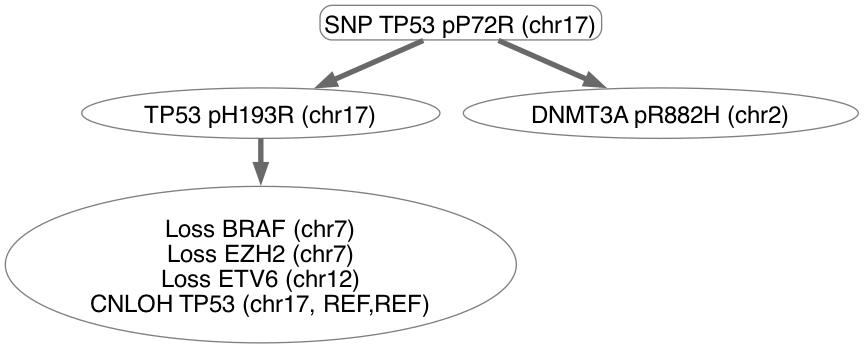

In [9]:
op.pl.show_tree(sol_COMPASS[op.ul.DATA.MUTATION_TREE])

In [10]:
sol_scaOrchard = op.tl.solver.scaOrchard(character_matrix.replace(2,1).replace(3,-1), 
                                         variant_reads_df, 
                                         total_reads_df,                        
                                         regions_df, 
                                         meta_df,
                                         cell_samples=cell_samples,
                                         remove_temp_dir=False,
                                         seed=0)

In [11]:
T = sol_scaOrchard[op.ul.DATA.MUTATION_TREE].copy()

In [12]:
sol_scaOrchard[op.ul.EVAL_KEYS.RUNTIME]

152.85420887498185

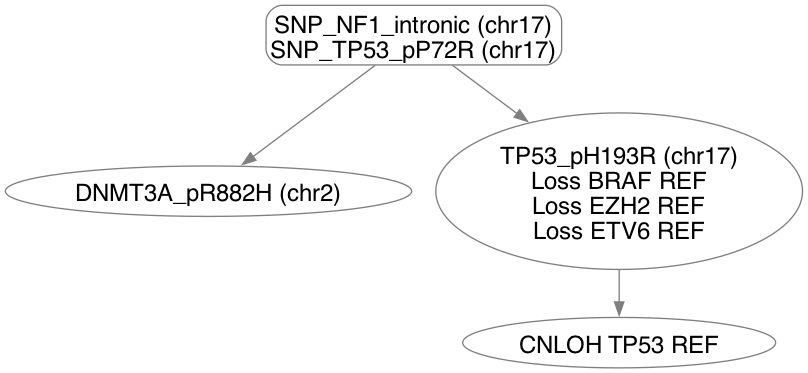

In [13]:
op.pl.show_tree(T)